# 01 — Exploração dos dados do VRA (ANAC)

Este notebook faz o reconhecimento dos microdados de Voo Regular Ativo antes de qualquer transformação: como os arquivos chegam, se o layout se mantém ao longo dos meses e em que estado estão as colunas que vão medir pontualidade. Nada aqui limpa, transforma ou calcula indicador — isso é assunto das próximas fases.

Trabalho com três meses distantes entre si (2023-01, 2024-07 e 2026-05). É o bastante para expor mudanças de estrutura sem carregar a série inteira na memória.

## 0. Configuração do ambiente

O notebook fica em `notebooks/`, mas o `config.py` está na raiz do projeto, então adiciono a pasta-pai ao `sys.path` para o import funcionar sem instalar o projeto como pacote. `DATA_RAW` aponta para os CSVs brutos, exatamente como baixados da ANAC. Essa pasta é imutável; qualquer saída de tratamento vai para `data/processed`.

In [ ]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent  
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from config import DATA_RAW


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Leitura e visão geral

Os CSVs da ANAC usam ponto e vírgula como separador, então `sep=";"` é obrigatório — sem ele o pandas lê o arquivo inteiro como uma coluna só. O `.info()` dá volume, tipos e contagem de não-nulos; o `.head()` mostra como os valores realmente aparecem.

Um detalhe que condiciona o resto do projeto: as quatro colunas de data/hora (`Partida Prevista`, `Partida Real`, `Chegada Prevista`, `Chegada Real`) chegam como texto no formato `DD/MM/AAAA HH:MM`. Enquanto forem texto, não dá para subtrair horários e calcular atraso. A conversão fica para a fase de tratamento.

In [ ]:
df1 = pd.read_csv(DATA_RAW / "2023-01.csv", sep = ";")
df2 = pd.read_csv(DATA_RAW / "2024-07.csv", sep = ";")
df3 = pd.read_csv(DATA_RAW / "2026-05.csv", sep = ";")


### 1.1 Estrutura de cada arquivo

Comparando os três meses, a diferença que salta é a quantidade de colunas: 20 em 2023-01 contra 21 nos outros dois. A extra é `Codeshare`, que passou a ser publicada depois. A concatenação dos meses vai ter que lidar com isso — o pandas até preenche com `NaN` sozinho, mas prefiro fixar o conjunto de colunas explicitamente na fase de tratamento.

`Justificativa` aparece com zero valores preenchidos e tipo `float64` (coluna inteiramente vazia vira numérica no pandas). Candidata a descarte.

In [ ]:
df1.info()


<class 'pandas.DataFrame'>
RangeIndex: 87647 entries, 0 to 87646
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sigla ICAO Empresa Aérea      87647 non-null  str    
 1   Empresa Aérea                 87647 non-null  str    
 2   Número Voo                    87647 non-null  str    
 3   Código DI                     87647 non-null  str    
 4   Código Tipo Linha             87647 non-null  str    
 5   Modelo Equipamento            87647 non-null  str    
 6   Número de Assentos            87647 non-null  int64  
 7   Sigla ICAO Aeroporto Origem   87647 non-null  str    
 8   Descrição Aeroporto Origem    87647 non-null  str    
 9   Partida Prevista              83908 non-null  str    
 10  Partida Real                  83210 non-null  str    
 11  Sigla ICAO Aeroporto Destino  87647 non-null  str    
 12  Descrição Aeroporto Destino   87647 non-null  str    
 13  Chegada Prev

In [ ]:
df2.info()


<class 'pandas.DataFrame'>
RangeIndex: 87683 entries, 0 to 87682
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sigla ICAO Empresa Aérea      87683 non-null  str    
 1   Empresa Aérea                 87683 non-null  str    
 2   Número Voo                    87683 non-null  str    
 3   Código DI                     87683 non-null  str    
 4   Código Tipo Linha             87683 non-null  str    
 5   Modelo Equipamento            87683 non-null  str    
 6   Número de Assentos            87683 non-null  int64  
 7   Sigla ICAO Aeroporto Origem   87683 non-null  str    
 8   Descrição Aeroporto Origem    87683 non-null  str    
 9   Partida Prevista              85241 non-null  str    
 10  Partida Real                  84599 non-null  str    
 11  Sigla ICAO Aeroporto Destino  87683 non-null  str    
 12  Descrição Aeroporto Destino   87683 non-null  str    
 13  Chegada Prev

In [ ]:
df3.info()


<class 'pandas.DataFrame'>
RangeIndex: 82120 entries, 0 to 82119
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sigla ICAO Empresa Aérea      82120 non-null  str    
 1   Empresa Aérea                 82120 non-null  str    
 2   Número Voo                    82120 non-null  str    
 3   Código DI                     82120 non-null  str    
 4   Código Tipo Linha             82120 non-null  str    
 5   Modelo Equipamento            82120 non-null  str    
 6   Número de Assentos            82120 non-null  int64  
 7   Sigla ICAO Aeroporto Origem   82120 non-null  str    
 8   Descrição Aeroporto Origem    82120 non-null  str    
 9   Partida Prevista              79877 non-null  str    
 10  Partida Real                  79731 non-null  str    
 11  Sigla ICAO Aeroporto Destino  82120 non-null  str    
 12  Descrição Aeroporto Destino   82120 non-null  str    
 13  Chegada Prev

### 1.2 Amostra dos dados

Três observações do `.head()` que afetam as próximas fases. `Número Voo` é texto com zeros à esquerda (`0904`); converter para número apaga os zeros e quebra a identificação do voo. As datas estão em formato brasileiro, então a conversão pede `format="%d/%m/%Y %H:%M"`. E logo na primeira linha há um voo que partiu antes do previsto — prevista `01/01/2023 00:05`, real `31/12/2022 23:59`. Diferença negativa é antecipação, não erro.

In [ ]:
df1.head()


,Sigla ICAO Empresa Aérea,Empresa Aérea,Número Voo,Código DI,Código Tipo Linha,Modelo Equipamento,Número de Assentos,Sigla ICAO Aeroporto Origem,Descrição Aeroporto Origem,Partida Prevista,Partida Real,Sigla ICAO Aeroporto Destino,Descrição Aeroporto Destino,Chegada Prevista,Chegada Real,Situação Voo,Justificativa,Referência,Situação Partida,Situação Chegada
0,AAL,"AMERICAN AIRLINES, INC.",0904,0,I,B788,295,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,01/01/2023 00:05,31/12/2022 23:59,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",01/01/2023 08:37,01/01/2023 08:12,REALIZADO,NaN,2023-01-01,Antecipado,Antecipado
1,AAL,"AMERICAN AIRLINES, INC.",0905,0,I,B788,295,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",01/01/2023 21:45,01/01/2023 00:56,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,02/01/2023 06:20,01/01/2023 09:03,REALIZADO,NaN,2023-01-01,Antecipado,Antecipado
2,AAL,"AMERICAN AIRLINES, INC.",0906,0,I,B77W,318,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,01/01/2023 00:00,31/12/2022 23:54,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",01/01/2023 06:30,01/01/2023 07:52,REALIZADO,NaN,2023-01-01,Antecipado,Atraso 60-120
3,AAL,"AMERICAN AIRLINES, INC.",0929,0,I,B77W,318,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",01/01/2023 21:45,01/01/2023 21:51,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,02/01/2023 06:20,02/01/2023 06:33,REALIZADO,NaN,2023-01-01,Pontual,Pontual
4,AAL,"AMERICAN AIRLINES, INC.",0930,0,I,B772,288,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,01/01/2023 22:00,01/01/2023 22:27,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",02/01/2023 06:55,02/01/2023 06:33,REALIZADO,NaN,2023-01-01,Pontual,Antecipado


### 1.3 Layout da série inteira

Três meses não garantem nada sobre os outros 38. Esta célula lê apenas o cabeçalho de cada CSV (`nrows=0`, rápido e sem custo de memória) e agrupa os meses por conjunto de colunas. Deram 2 layouts: existe um antes e um depois da inclusão do `Codeshare`. Melhoria pendente: imprimir quais meses caem em cada grupo, para o dicionário registrar onde está a quebra.

In [ ]:
headers = {}

for arq in sorted(DATA_RAW.glob("2*.csv")):
    cols = pd.read_csv(arq, sep=";", nrows=0)
    headers[arq.stem] = cols

# agrupar meses por layout
import collections
layouts = collections.Counter(tuple(c) for c in headers.values())
print(len(layouts), "layouts diferentes")


2 layouts diferentes


### 1.4 Quais meses estão em cada layout

O `Counter` diz quantos layouts existem, mas não onde a série muda. Agrupando os meses pelo conjunto de colunas dá para registrar a fronteira exata no dicionário. A transição não é limpa: os dez meses sem `Codeshare` são 2023-01 a 2023-04 e 2023-06 a 2023-11 — 2023-05 já veio com a coluna, os vizinhos não. De 2023-12 em diante todos os meses a têm.

In [ ]:
grupos = {}
for mes, cols in headers.items():
    grupos.setdefault(tuple(cols), []).append(mes)

for cols, meses in grupos.items():
    print(f"{len(cols)} colunas — {len(meses)} meses: {', '.join(meses)}\n")

layout_a, layout_b = grupos.keys()
print("Diferença entre os layouts:", set(layout_a) ^ set(layout_b))

## 2. Qualidade: nulos, duplicados e categorias

Nulo não é problema por definição; o que importa é a causa. Um voo cancelado sem horário real de partida é informação correta. Já um voo marcado como realizado sem horário seria inconsistência, e precisaria de regra de tratamento. As células desta seção seguem sempre esse caminho: medir primeiro, procurar a explicação de negócio depois.

### 2.1 Nulos e duplicados

Uso percentual de nulos em vez de contagem absoluta — 4 mil nulos pesam diferente conforme o tamanho da base.

Duplicados, duas checagens. Linha inteira repetida: zero, ou seja, sem falha de extração. Chave de negócio (empresa + número do voo + partida prevista + origem + destino): 1.768 repetições. Esse número precisa de investigação antes de qualquer agregação, porque voo contado duas vezes infla indicador. A suspeita inicial fica registrada aqui e a investigação, na seção seguinte.

In [ ]:
# % de nulos por coluna
print("% Nulos por coluna: \n",(df1.isna().mean() * 100).round(2).sort_values(ascending=False))
# duplicados — linha inteira e por chave de negócio
print("\nLinhas duplicadas: \n", df1.duplicated().sum())
chave = ["Sigla ICAO Empresa Aérea", "Número Voo", "Partida Prevista",
         "Sigla ICAO Aeroporto Origem", "Sigla ICAO Aeroporto Destino"]

print("\nLinhas de Chave de negócio duplicadas: \n", df1.duplicated(subset=chave).sum())


% Nulos por coluna: 
 Justificativa                   100.00
Situação Partida                  9.33
Situação Chegada                  9.33
Partida Real                      5.06
Chegada Real                      5.06
Partida Prevista                  4.27
Chegada Prevista                  4.27
Sigla ICAO Empresa Aérea          0.00
Código DI                         0.00
Número Voo                        0.00
Empresa Aérea                     0.00
Código Tipo Linha                 0.00
Sigla ICAO Aeroporto Destino      0.00
Descrição Aeroporto Origem        0.00
Número de Assentos                0.00
Sigla ICAO Aeroporto Origem       0.00
Modelo Equipamento                0.00
Descrição Aeroporto Destino       0.00
Situação Voo                      0.00
Referência                        0.00
dtype: float64

Linhas duplicadas: 
 0

Linhas de Chave de negócio duplicadas: 
 1768


### 2.2 Categóricas

O `dropna=False` é essencial: sem ele o `value_counts()` esconde justamente os nulos que queremos ver.

`Situação Voo` fecha em REALIZADO 83.210, CANCELADO 4.386 e NÃO INFORMADO 51 — e 83.210 é exatamente o total de não-nulos de `Partida Real`, primeira pista de que os horários ausentes são os cancelados. `Situação Partida` e `Situação Chegada` já vêm classificadas em faixas pela ANAC, o que abre uma decisão de projeto: usar a faixa pronta ou calcular o atraso em minutos a partir dos horários. Calcular dá mais flexibilidade; a faixa pronta garante alinhamento com a publicação oficial.

Um número não fecha de cara: 8.176 nulos nas colunas de situação, contra 4.437 voos sem horário real. Sobram 3.739 voos com horário preenchido e situação em branco — são exatamente os registros sem `Partida Prevista` (voos extras, códigos DI 1 a 6): sem horário previsto não há referência para classificar atraso. Ou seja, situação nula = falta de prevista ou falta de real, e os totais fecham (4.437 + 3.739 = 8.176).

`Código DI` e `Código Tipo Linha` pedem consulta ao dicionário oficial da ANAC antes de qualquer filtro.

In [ ]:
for col in ["Situação Voo", "Situação Partida", "Situação Chegada", "Código DI", "Código Tipo Linha"]:
    print(f"\nColuna: {col}")
    display(df1[col].value_counts(dropna=False).to_frame())



Coluna: Situação Voo


,count
Situação Voo,
REALIZADO,83210
CANCELADO,4386
NÃO INFORMADO,51



Coluna: Situação Partida


,count
Situação Partida,
Antecipado,39551
Pontual,32637
NaN,8176
Atraso 30-60,4637
Atraso 60-120,1840
Atraso 120-240,590
Atraso > 240,216



Coluna: Situação Chegada


,count
Situação Chegada,
Antecipado,42006
Pontual,29636
NaN,8176
Atraso 30-60,5029
Atraso 60-120,1960
Atraso 120-240,615
Atraso > 240,225



Coluna: Código DI


,count
Código DI,
0,83076
2,2051
1,531
7,474
6,453
3,334
9,324
4,310
D,74



Coluna: Código Tipo Linha


,count
Código Tipo Linha,
N,72088
I,10979
G,1983
C,1890
X,707


### 2.3 Os nulos são cancelamentos?

Em vez de confiar na coincidência dos totais, o filtro direto: dos voos sem `Partida Real`, qual é a situação declarada? Só CANCELADO (4.386) e NÃO INFORMADO (51). Nenhum REALIZADO. Horário ausente aqui é consequência do cancelamento, não falha de coleta.

In [ ]:
# Cruzar nulos de partida real com voos cancelados
display(df1[df1['Partida Real'].isna()]["Situação Voo"].value_counts().to_frame())


,count
Situação Voo,
CANCELADO,4386
NÃO INFORMADO,51


### 2.4 Consistência nos dois sentidos

Faltava o teste inverso. Os dois abaixo devem retornar zero: voo NÃO INFORMADO com horário preenchido e voo REALIZADO sem horário. Retornaram zero. A relação entre situação e presença de horário é consistente nas duas direções — um teste sozinho pode passar por coincidência, dois complementares dificilmente passam.

In [ ]:
# Checar partida de não informados
voos_n_informados = df1[
    (df1["Situação Voo"] == "NÃO INFORMADO") & 
    (df1["Partida Real"].notna())
]["Partida Real"]

print(f"Voos realizados sem situação de voo informada: {len(voos_n_informados)}")


Voos realizados sem situação de voo informada: 0


In [ ]:
problema = df1[
    (df1["Partida Real"].isna()) &
    (df1["Situação Voo"] == "REALIZADO")
]

print(f"Voos realizados sem partida real preenchida: {len(problema)}")


Voos realizados sem partida real preenchida: 0


### 2.5 De onde vêm os duplicados de chave e as situações em branco

As duas pendências anteriores têm a mesma raiz. Os 3.739 voos com horário real e situação em branco são exatamente os registros sem `Partida Prevista` — voos extras, sem horário publicado. Sem previsão não existe referência para classificar atraso, e os totais fecham: 4.437 sem horário real mais 3.739 sem prevista dão os 8.176 nulos de situação.

O mesmo vale para a chave: das 2.269 linhas envolvidas em duplicidade, 2.267 não têm `Partida Prevista`. Como a prevista faz parte da chave, todos os voos extras de uma mesma rota colidem entre si. Sobra um único par de duplicata verdadeira no mês. A regra que fica para o tratamento é separar os voos sem prevista antes de qualquer análise de pontualidade, em vez de tratá-los como repetição.

In [ ]:
sem_situacao = df1["Partida Real"].notna() & df1["Situação Partida"].isna()
print("Com horário real e situação em branco:", sem_situacao.sum())
print("Desses, sem partida prevista:", df1[sem_situacao]["Partida Prevista"].isna().sum())

In [ ]:
dups = df1[df1.duplicated(subset=chave, keep=False)]
print("Linhas envolvidas em duplicidade de chave:", len(dups))
print("Dessas, sem partida prevista:", dups["Partida Prevista"].isna().sum())

### 2.6 O que sobrou das colunas

Três colunas ainda não tinham sido olhadas. `Modelo Equipamento` tem 50 valores distintos no mês. `Referência` é apenas a data da etapa: 31 valores, um por dia de janeiro. A surpresa está em `Número de Assentos`: 5.214 registros com zero assentos (5,9% do mês), a maioria voos regulares realizados. Pode ser convenção da ANAC para certos tipos de operação — voos cargueiros, por exemplo — e o cruzamento com `Código Tipo Linha` fica como pendência. Enquanto isso, a coluna não deve alimentar nenhuma métrica de oferta de assentos sem filtro.

In [ ]:
print("Modelos de aeronave distintos:", df1["Modelo Equipamento"].nunique())

assentos = df1["Número de Assentos"].astype(int)
print(f"Registros com zero assentos: {(assentos == 0).sum()} ({(assentos == 0).mean():.1%})")

print("Valores distintos em Referência:", df1["Referência"].nunique())
print("Intervalo de Referência:", df1["Referência"].min(), "a", df1["Referência"].max())

## 3. Datas, antecipações e meia-noite

Conversão das quatro colunas de data com `errors="coerce"` e cálculo do atraso de partida em minutos. O que procurar: NaT criados pela conversão além dos nulos originais (indicariam data malformada), o volume de antecipações e valores extremos.

In [ ]:
df1.head(3)


,Sigla ICAO Empresa Aérea,Empresa Aérea,Número Voo,Código DI,Código Tipo Linha,Modelo Equipamento,Número de Assentos,Sigla ICAO Aeroporto Origem,Descrição Aeroporto Origem,Partida Prevista,Partida Real,Sigla ICAO Aeroporto Destino,Descrição Aeroporto Destino,Chegada Prevista,Chegada Real,Situação Voo,Justificativa,Referência,Situação Partida,Situação Chegada
0,AAL,"AMERICAN AIRLINES, INC.",0904,0,I,B788,295,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,01/01/2023 00:05,31/12/2022 23:59,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",01/01/2023 08:37,01/01/2023 08:12,REALIZADO,NaN,2023-01-01,Antecipado,Antecipado
1,AAL,"AMERICAN AIRLINES, INC.",0905,0,I,B788,295,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",01/01/2023 21:45,01/01/2023 00:56,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,02/01/2023 06:20,01/01/2023 09:03,REALIZADO,NaN,2023-01-01,Antecipado,Antecipado
2,AAL,"AMERICAN AIRLINES, INC.",0906,0,I,B77W,318,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,01/01/2023 00:00,31/12/2022 23:54,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",01/01/2023 06:30,01/01/2023 07:52,REALIZADO,NaN,2023-01-01,Antecipado,Atraso 60-120


In [ ]:
df1.columns


Index(['Sigla ICAO Empresa Aérea', 'Empresa Aérea', 'Número Voo', 'Código DI',
       'Código Tipo Linha', 'Modelo Equipamento', 'Número de Assentos',
       'Sigla ICAO Aeroporto Origem', 'Descrição Aeroporto Origem',
       'Partida Prevista', 'Partida Real', 'Sigla ICAO Aeroporto Destino',
       'Descrição Aeroporto Destino', 'Chegada Prevista', 'Chegada Real',
       'Situação Voo', 'Justificativa', 'Referência', 'Situação Partida',
       'Situação Chegada'],
      dtype='str')

In [ ]:
for col in ["Partida Prevista", "Partida Real", "Chegada Prevista", "Chegada Real"]:
    df1[col] = pd.to_datetime(df1[col], format="%d/%m/%Y %H:%M", errors = "coerce")

df1["Atraso_partida_min"] = (df1["Partida Real"] - df1["Partida Prevista"]).dt.total_seconds() / 60
df1["Atraso_partida_min"].describe()


count    79471.000000
mean         5.296309
std         69.335954
min      -1575.000000
25%         -5.000000
50%          0.000000
75%         10.000000
max       1726.000000
Name: Atraso_partida_min, dtype: float64

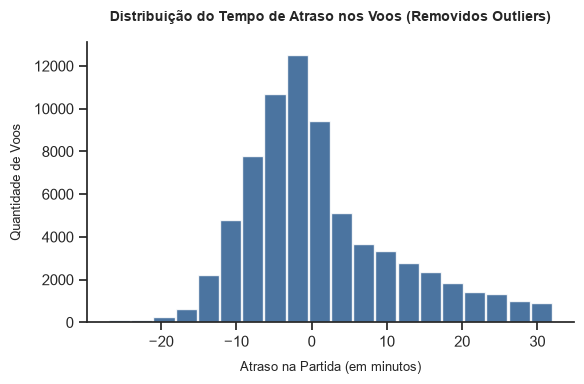

In [ ]:
# Quartis e IQR
q1 = df1["Atraso_partida_min"].quantile(0.25)
q3 = df1["Atraso_partida_min"].quantile(0.75)
iqr = q3 - q1

# Limites das extremidades
lim_sup = q3 + 1.5 * iqr
lim_inf = q1 - 1.5 * iqr


# 1. Configura o estilo e o tamanho da imagem
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 4), dpi=100)

# 2. Filtra os dados e plota o histograma com cor moderna (Steel Blue)
dados_plot = df1[(df1["Atraso_partida_min"] > lim_inf) & (df1["Atraso_partida_min"] < lim_sup)]["Atraso_partida_min"]

# plt.hist do matplotlib dá mais controle sobre o visual do que o .hist() direto do pandas
plt.hist(dados_plot, bins=20, color="#2b5c8f", edgecolor="white", alpha=0.85, rwidth=0.95)

# 3. Adiciona títulos explicativos (e remove termos técnicos do título principal)
plt.title("Distribuição do Tempo de Atraso nos Voos (Removidos Outliers)", fontsize=10, pad=15, fontweight="bold")
plt.xlabel("Atraso na Partida (em minutos)", fontsize=9, labelpad=8)
plt.ylabel("Quantidade de Voos", fontsize=9, labelpad=8)

# 4. Melhora os eixos e remove as bordas superior e direita (Visual Clean)
sns.despine()

# 5. Garante que os textos não fiquem cortados na hora de exibir
plt.tight_layout()
plt.show()


In [96]:
colunas_datas = ["Partida Prevista", "Partida Real", "Chegada Prevista", "Chegada Real"]

# dataframe original
df_datas_originais = pd.read_csv(DATA_RAW / "2023-01.csv", sep = ";", usecols = colunas_datas)

# Cria listas para guardar as contagens de nulos
nulos_originais = []
nulos_convertidos = []

for col in colunas_datas:
    nulos_originais.append(df_datas_originais[col].isna().sum())
    nulos_convertidos.append(df1[col].isna().sum())

# Montar o relatório

df_comparacao = pd.DataFrame(
    {
    "Coluna" : colunas_datas,
    "Nulos Originais" :  nulos_originais,
    "Nulos Convertidos" : nulos_convertidos
    }
)
df_comparacao['Diferença'] = df_comparacao['Nulos Convertidos'] - df_comparacao['Nulos Originais']

display(df_comparacao)


,Coluna,Nulos Originais,Nulos Convertidos,Diferença
0,Partida Prevista,3739,3739,0
1,Partida Real,4437,4437,0
2,Chegada Prevista,3739,3739,0
3,Chegada Real,4437,4437,0


### 3.1 Antecipações

Quase metade dos voos parte antes do horário previsto: 39.551 em janeiro de 2023, 45,1% das linhas do mês (47,5% entre os voos realizados). O número bate exatamente com a categoria `Antecipado` da própria ANAC, o que valida o cálculo — e o padrão se repete em outros meses da série.

O efeito sobre a média é o motivo de o README exigir métricas separadas: incluindo antecipações, o atraso médio do mês é de 5,3 minutos; considerando só quem partiu no horário ou depois, 21,5. A média única esconde o atraso real de quem atrasa.

In [ ]:
antecipados = df1["Atraso_partida_min"] < 0
print(f"Atraso negativo: {antecipados.sum()} ({antecipados.mean():.1%} das linhas do mês)")
print("Categoria 'Antecipado' da ANAC:", (df1["Situação Partida"] == "Antecipado").sum())
print(f"Média geral do atraso: {df1['Atraso_partida_min'].mean():.1f} min")
print(f"Média sem antecipações: {df1.loc[df1['Atraso_partida_min'] >= 0, 'Atraso_partida_min'].mean():.1f} min")

### 3.2 Virada de meia-noite e valores extremos

Como as colunas trazem a data completa junto com a hora, a duração de voos que cruzam a meia-noite sai correta por subtração direta — nenhuma chegada real anterior à partida real no mês. Restam os extremos: 15 voos com atraso de partida acima de 24 horas. São poucos, mas puxam qualquer média; a fase de tratamento decide se viram outlier documentado ou permanecem como estão.

In [ ]:
print("Chegada real anterior à partida real:", (df1["Chegada Real"] < df1["Partida Real"]).sum())

extremos = df1[df1["Atraso_partida_min"] > 24 * 60]
print("Atrasos de partida acima de 24h:", len(extremos))
extremos[["Sigla ICAO Empresa Aérea", "Número Voo", "Partida Prevista", "Partida Real", "Situação Partida"]]

## 4. Codeshare

A coluna que só existe a partir de 2023-05 ainda não tinha sido aberta. Uso 2026-05, onde ela vem preenchida. Metade dos registros é nula (40.554 de 82.120); a outra metade traz o voo comercial da empresa parceira que vende assentos naquela operação, no formato `SIGLA/NÚMERO`, às vezes em lista (`FIN/5892, IBE/3607`). São 10.839 combinações distintas.

Para a pontualidade a coluna é descritiva: o voo operado é um só. O que ela sugere — hipótese a confirmar no tratamento — é que o VRA registra cada operação uma única vez, com os parceiros comerciais anotados, e não uma linha por voo vendido.

### 3.3 Os mesmos testes nos outros dois meses

Tudo até aqui usou janeiro de 2023. Antes de transformar esses achados em regra no dicionário, repito as quatro verificações de datas em 2024-07 e 2026-05: datas inválidas geradas na conversão, antecipações calculadas contra a categoria da ANAC, chegadas anteriores à partida e atrasos acima de 24 horas.

O resultado sustenta as conclusões. Nenhuma data inválida, nenhuma chegada antes da partida, o cálculo de antecipação bate com a categoria oficial nos dois meses — e em ambos as antecipações passam de metade das linhas (46.555 e 44.347). Os atrasos extremos variam de 8 a 25 voos por mês.

In [ ]:
for nome, df_mes in [("2024-07", df2), ("2026-05", df3)]:
    convertido = df_mes.copy()
    for col in ["Partida Prevista", "Partida Real", "Chegada Prevista", "Chegada Real"]:
        convertido[col] = pd.to_datetime(convertido[col], format="%d/%m/%Y %H:%M", errors="coerce")

    nat_extras = convertido["Partida Real"].isna().sum() - df_mes["Partida Real"].isna().sum()
    atraso = (convertido["Partida Real"] - convertido["Partida Prevista"]).dt.total_seconds() / 60

    print(f"{nome}")
    print("  datas inválidas geradas na conversão:", nat_extras)
    print(f"  antecipações calculadas: {(atraso < 0).sum()} | categoria da ANAC: {(df_mes['Situação Partida'] == 'Antecipado').sum()}")
    print("  chegada real antes da partida real:", (convertido["Chegada Real"] < convertido["Partida Real"]).sum())
    print(f"  atrasos de partida acima de 24h: {(atraso > 24 * 60).sum()}\n")

In [ ]:
vc = df3["Codeshare"].value_counts(dropna=False)
print("Valores distintos:", len(vc))
print(f"Nulos: {df3['Codeshare'].isna().sum()} de {len(df3)} ({df3['Codeshare'].isna().mean():.1%})")
df3["Codeshare"].dropna().head(10)

## 5. Cadastros, escopo doméstico e chaves órfãs

Os dois cadastros baixados na ingestão entram agora. O de aeródromos tem 10.560 registros e cobre o mundo inteiro — 3.548 são brasileiros — com sigla ICAO, nome, município, estado, país e coordenadas. O de operadores é pequeno: 70 empresas com sigla ICAO, IATA, nome e país-sede.

In [ ]:
aerodromos = pd.read_csv(DATA_RAW / "aerodromos.csv", sep=";")
empresas = pd.read_csv(DATA_RAW / "empresas.csv", sep=";")

print("Aeródromos:", aerodromos.shape, "| Empresas:", empresas.shape)
print("Aeródromos brasileiros:", (aerodromos["PAÍS AERÓDROMO"] == "BRASIL").sum())
aerodromos.head(3)

### 5.1 Dois critérios para "voo doméstico"

Há duas formas de identificar um voo doméstico: pelo prefixo da sigla ICAO (aeroportos brasileiros de maior porte começam com SB) ou pelo país do aeródromo no cadastro. Os critérios divergem em 1.913 linhas do mês, porque aeródromos pequenos como SNCL (Lençóis) e SDLO são brasileiros sem ter prefixo SB.

O critério do cadastro é o mais correto e fica como decisão para o dicionário: doméstico é o voo cujos dois aeródromos têm país BRASIL no cadastro. Em janeiro de 2023 isso cobre 84,6% dos registros; o escopo do projeto exclui os 15,4% restantes.

In [ ]:
origem = df1["Sigla ICAO Aeroporto Origem"]
destino = df1["Sigla ICAO Aeroporto Destino"]

dom_prefixo = origem.str.startswith("SB") & destino.str.startswith("SB")

brasileiros = set(aerodromos.loc[aerodromos["PAÍS AERÓDROMO"] == "BRASIL", "SIGLA ICAO AERÓDROMO"])
dom_cadastro = origem.isin(brasileiros) & destino.isin(brasileiros)

print(f"Prefixo SB: {dom_prefixo.sum()} ({dom_prefixo.mean():.1%})")
print(f"País BRASIL no cadastro: {dom_cadastro.sum()} ({dom_cadastro.mean():.1%})")
print("Linhas em que os critérios divergem:", (dom_prefixo ^ dom_cadastro).sum())
df1[dom_prefixo ^ dom_cadastro][["Sigla ICAO Aeroporto Origem", "Sigla ICAO Aeroporto Destino"]].drop_duplicates().head()

### 5.2 Chaves órfãs

Todos os 258 aeroportos citados no VRA de janeiro existem no cadastro — zero órfãos, inclusive os estrangeiros, já que o cadastro do SIROS é mundial. A premissa de que aeroportos de fora ficariam sem correspondência não se confirmou.

Nas empresas a história é outra: 19 siglas do VRA não estão no cadastro de operadores, somando 2.425 linhas (2,8% do mês). Isso não bloqueia a análise, que se apoia nos códigos de aeroporto, mas um join com o cadastro de empresas perderia essas linhas. A regra de tratamento precisa escolher entre join à esquerda ou uma tabela auxiliar com as siglas faltantes.

In [ ]:
orfaos_aero = (set(origem) | set(destino)) - set(aerodromos["SIGLA ICAO AERÓDROMO"])
print("Aeroportos do VRA fora do cadastro:", len(orfaos_aero))

orfas_emp = set(df1["Sigla ICAO Empresa Aérea"]) - set(empresas["ICAO OPERADOR AÉREO"])
linhas_orfas = df1["Sigla ICAO Empresa Aérea"].isin(orfas_emp).sum()
print(f"Empresas do VRA fora do cadastro: {len(orfas_emp)} siglas, {linhas_orfas} linhas ({linhas_orfas / len(df1):.1%})")
print(sorted(orfas_emp))

## 6. O que vai para o dicionário

O layout muda uma vez na série (coluna `Codeshare`, com transição irregular durante 2023). Os horários estão em horário de Brasília, como texto no padrão brasileiro, e a subtração direta funciona porque a data completa acompanha a hora. Nulos de horário são cancelamentos; situações em branco são voos sem horário previsto; os duplicados de chave são, na prática, esses mesmos voos extras colidindo na chave. Quase metade dos voos parte adiantada, o que obriga métricas separadas de atraso. O escopo doméstico será definido pelo país do aeródromo no cadastro, não pelo prefixo da sigla. E o cadastro de empresas não cobre todas as siglas do VRA, o que condiciona o tipo de join. Cada um desses pontos vira uma entrada de decisão no `docs/dicionario_dados.md`.